# 1. Statistical Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

df = pd.read_csv('/content/Google-Playstore-Cleaned.csv', encoding='latin1', low_memory=False)

print("Columns loaded:", df.columns.tolist())

Columns loaded: ['App Name', 'App Id', 'Category', 'Rating', 'Rating Count', 'Installs', 'Minimum Installs', 'Maximum Installs', 'Free', 'Price', 'Currency', 'Size', 'Minimum Android', 'Developer Id', 'Developer Website', 'Developer Email', 'Released', 'Last Updated', 'Content Rating', 'Privacy Policy', 'Ad Supported', 'In App Purchases', 'Editors Choice', 'Scraped Time', 'Size_MB', 'Installs_Numeric']


# 2. Hypothesis Testing: Satisfaction Analysis

## 2.1 T-Test: Rating Difference (Free vs Paid)

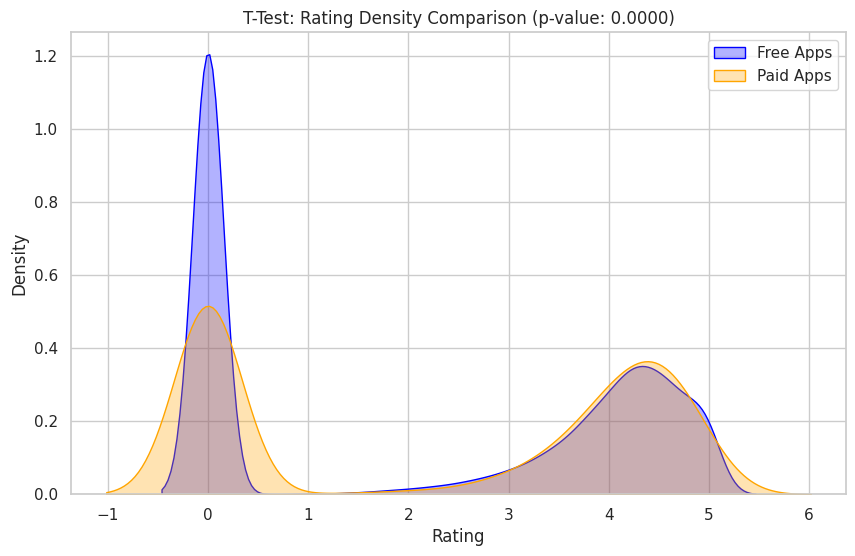

In [2]:
free_ratings = df[df['Free'] == True]['Rating'].dropna()
paid_ratings = df[df['Free'] == False]['Rating'].dropna()

t_stat, p_val = stats.ttest_ind(free_ratings, paid_ratings)

plt.figure(figsize=(10, 6))
sns.kdeplot(free_ratings, label='Free Apps', fill=True, color='blue', alpha=0.3)
sns.kdeplot(paid_ratings, label='Paid Apps', fill=True, color='orange', alpha=0.3)
plt.title(f'T-Test: Rating Density Comparison (p-value: {p_val:.4f})')
plt.legend()
plt.show()

## 2.2 Chi-Squared Test: Ad Support vs. Editors Choice

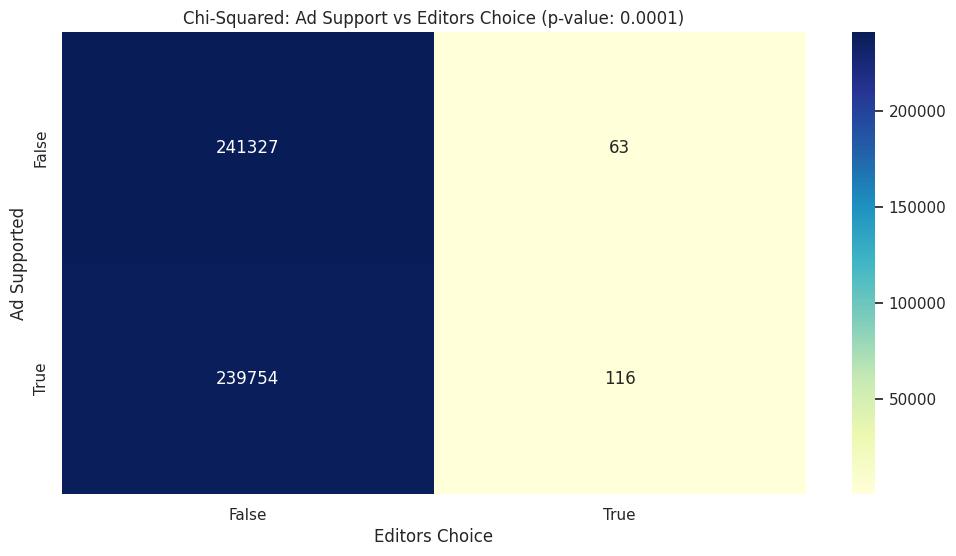

In [3]:
contingency_table = pd.crosstab(df['Ad Supported'], df['Editors Choice'])
chi2, p, dof, ex = stats.chi2_contingency(contingency_table)

sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlGnBu')
plt.title(f'Chi-Squared: Ad Support vs Editors Choice (p-value: {p:.4f})')
plt.show()

# 3. Regression Analysis (Root Cause Analysis)

## 3.1 Multiple Linear Regression

In [4]:
X = df[['Size_MB', 'Price']].fillna(0)
X = sm.add_constant(X)
y = np.log1p(df['Rating Count'])
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           Rating Count   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     3023.
Date:                Wed, 22 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:24:44   Log-Likelihood:            -1.1341e+06
No. Observations:              481261   AIC:                         2.268e+06
Df Residuals:                  481258   BIC:                         2.268e+06
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.9795      0.005    420.846      0.0

## 3.2 Regression Residual Plot

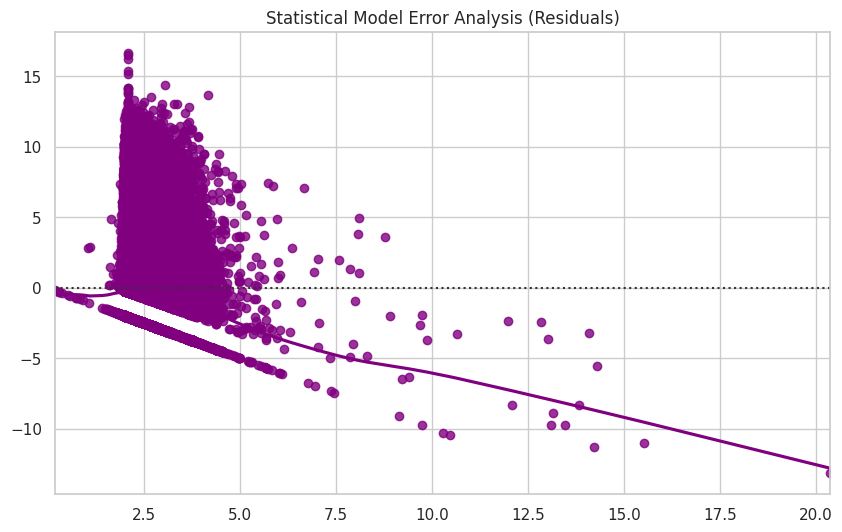

In [5]:
plt.figure(figsize=(10, 6))
sns.residplot(x=model.predict(), y=model.resid, lowess=True, color="purple")
plt.title('Statistical Model Error Analysis (Residuals)')
plt.show()

# 4. Strategic Market Segmentation and Density Profiling

## 4.1 Quality Variance Across High-Volume Categories

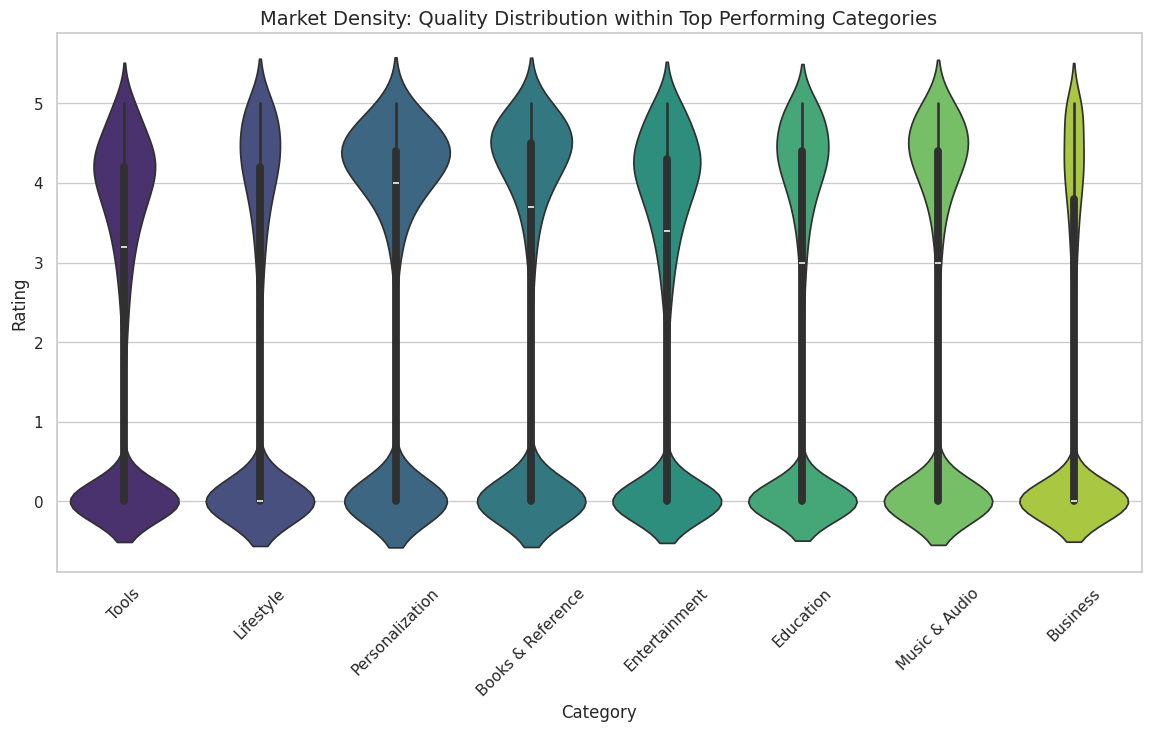

In [6]:
top_cats = df['Category'].value_counts().head(8).index
subset = df[df['Category'].isin(top_cats)]

plt.figure(figsize=(14, 7))
sns.violinplot(x='Category', y='Rating', data=subset, hue='Category', palette='viridis', legend=False)
plt.title('Market Density: Quality Distribution within Top Performing Categories', fontsize=14)
plt.xticks(rotation=45)
plt.show()

## 4.2 Pricing Elasticity and Satisfaction Density

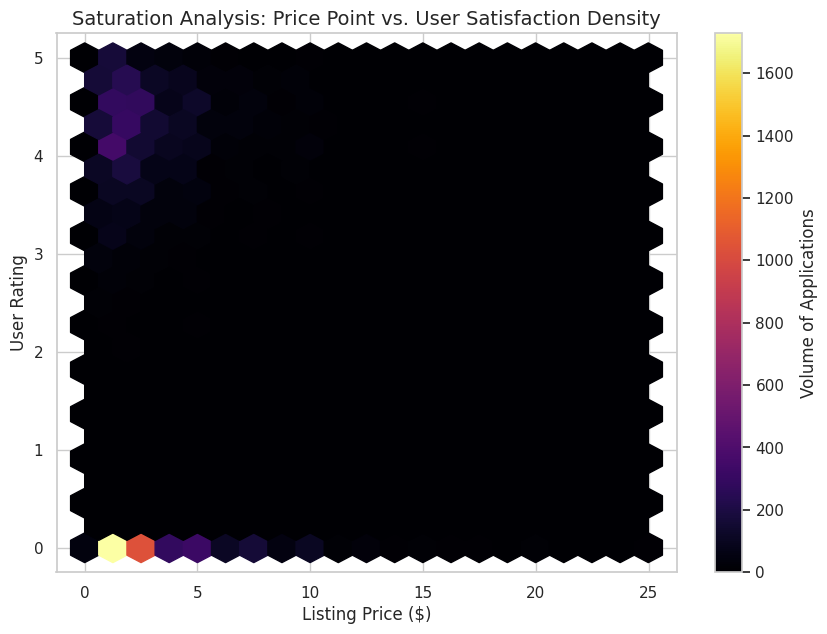

In [7]:
paid_market = df[(df['Free'] == False) & (df['Price'] < 25)]

plt.figure(figsize=(10, 7))
plt.hexbin(paid_market['Price'], paid_market['Rating'], gridsize=20, cmap='inferno')
plt.colorbar(label='Volume of Applications')
plt.title('Saturation Analysis: Price Point vs. User Satisfaction Density', fontsize=14)
plt.xlabel('Listing Price ($)')
plt.ylabel('User Rating')
plt.show()

## 4.3 Inter-variable Multicollinearity Assessment

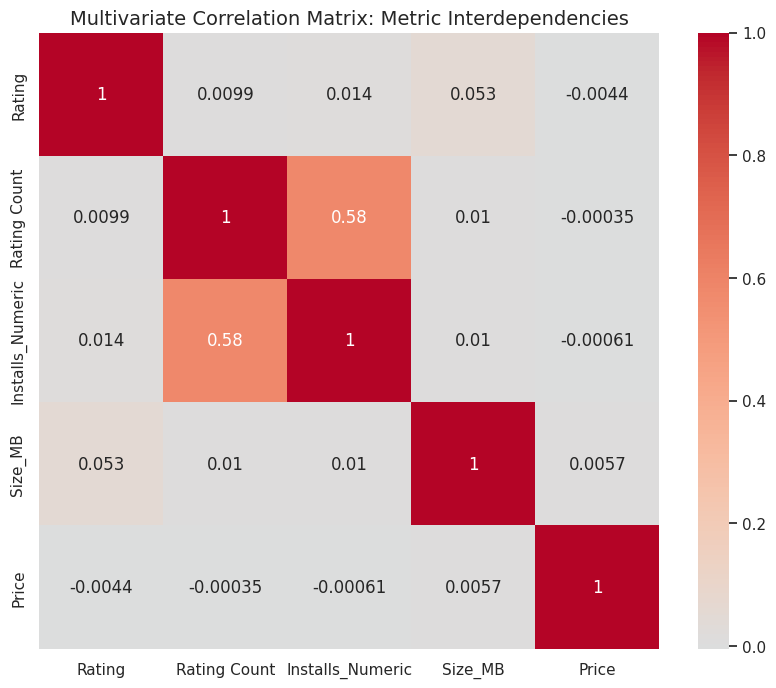

In [8]:
plt.figure(figsize=(10, 8))
corr_metrics = ['Rating', 'Rating Count', 'Installs_Numeric', 'Size_MB', 'Price']
sns.heatmap(df[corr_metrics].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Multivariate Correlation Matrix: Metric Interdependencies', fontsize=14)
plt.show()

# 5. Quantitative Performance Benchmarking (KPI Framework)

## 5.1 KPI Extraction for Strategic Reporting

In [9]:
# KPI 1: Market Success Benchmark (High Quality Threshold)
df['Success_Flag'] = (df['Rating'] >= 4.0).astype(int)
total_success_rate = df['Success_Flag'].mean() * 100

# KPI 2: User Engagement Coefficient (Conversion of Install to Feedback)
df['Feedback_Ratio'] = df['Rating Count'] / (df['Installs_Numeric'] + 1)
avg_feedback_ratio = df['Feedback_Ratio'].mean()

print(f"Calculated Success Rate (Ratings >= 4.0): {total_success_rate:.2f}%")
print(f"Average User Feedback Coefficient: {avg_feedback_ratio:.4f}")

Calculated Success Rate (Ratings >= 4.0): 35.38%
Average User Feedback Coefficient: 0.4413
